In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------- USER INPUT --------
emory_file = "/hpc/home/yy450/link_kamaleswaranlab/EmoryDataset/EMR_RAW/2022/CJSEPSIS_INFUSIONMEDS_2022.dsv"
mimic_file = "/hpc/home/yy450/link_kamaleswaranlab/mimic_iv/mimic_flat_files/INFUSIONMEDS/df_vasopressor_meds.csv"
# ----------------------------

# Load DataFrames
df_emory = pd.read_csv(emory_file, sep='|')
df_mimic = pd.read_csv(mimic_file)

print(f"✅ Loaded Emory: {df_emory.shape}, MIMIC: {df_mimic.shape}")
print(f"📋 Emory Columns: {list(df_emory.columns)}")
print(f"📋 MIMIC Columns: {list(df_mimic.columns)}")

# 🧪 Filter Emory by medication_id
if "medication_id" not in df_emory.columns:
    raise ValueError("'medication_id' column not found in Emory file.")

✅ Loaded Emory: (6790394, 18), MIMIC: (839543, 16)
📋 Emory Columns: ['pat_id', 'csn', 'order_med_id', 'medication_id', 'med_name', 'formulary_code', 'formulary_name', 'med_name_generic', 'med_order_time', 'med_action_time', 'med_action_code', 'med_action', 'med_start', 'med_stop', 'med_order_route_c', 'med_order_route', 'med_action_dose', 'med_action_dose_unit']
📋 MIMIC Columns: ['stay_id', 'med_order_time', 'dopamine', 'epinephrine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'dobutamine', 'dopamine_dose_unit', 'epinephrine_dose_unit', 'norepinephrine_dose_unit', 'phenylephrine_dose_unit', 'vasopressin_dose_unit', 'dobutamine_dose_unit', 'pat_id', 'csn']


In [71]:

# Emory analysis: list of medication IDs to filter by
emory_medication_ids = [2208305]  # <-- 可以添加多个，例如 [2196639, 2196640, 2196641]
emory_col = "med_action_dose_unit"
# emory_col = "med_action_dose"

# MIMIC analysis: directly analyze this column
mimic_col = "vasopressin_dose_unit"

In [72]:


df_emory_filtered = df_emory[df_emory["medication_id"].isin(emory_medication_ids)]
print(f"🔍 Emory rows after filtering by medication_id {emory_medication_ids}: {df_emory_filtered.shape[0]} rows")

# Check column existence
if emory_col not in df_emory_filtered.columns:
    raise ValueError(f"'{emory_col}' not found in Emory file (after filtering).")
if mimic_col not in df_mimic.columns:
    raise ValueError(f"'{mimic_col}' not found in MIMIC file.")

# Extract target columns
e_col = df_emory_filtered[emory_col]
m_col = df_mimic[mimic_col]


🔍 Emory rows after filtering by medication_id [2208305]: 59900 rows


In [73]:

# -- 1. Null Count --
print("\n🧼 Null Counts:")
print(f"Emory - {emory_col}: {e_col.isnull().sum()} nulls out of {len(e_col)}")
print(f"MIMIC - {mimic_col}: {m_col.isnull().sum()} nulls out of {len(m_col)}")



🧼 Null Counts:
Emory - med_action_dose_unit: 0 nulls out of 59900
MIMIC - vasopressin_dose_unit: 0 nulls out of 839543


In [74]:

# -- 2. Summary Stats --
print("\n📊 Summary Statistics:")
print("\nEmory:")
display(e_col.describe(include='all'))
print("\nMIMIC:")
display(m_col.describe(include='all'))



📊 Summary Statistics:

Emory:


count            59900
unique               2
top       Not Recorded
freq             52558
Name: med_action_dose_unit, dtype: object


MIMIC:


count         839543
unique             1
top       units/hour
freq          839543
Name: vasopressin_dose_unit, dtype: object

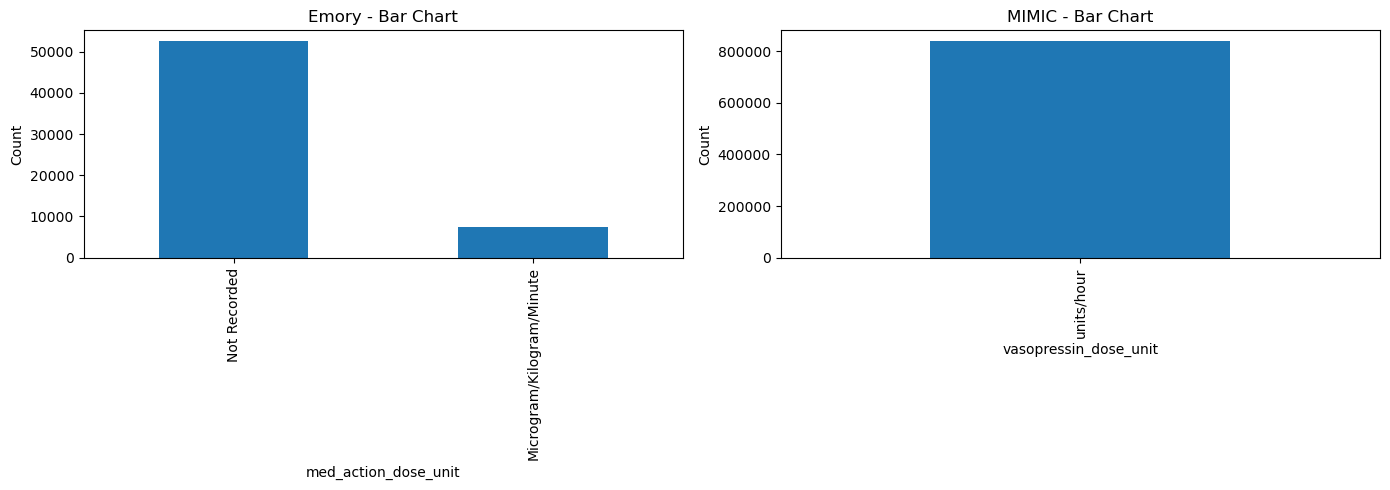

In [75]:
def plot_column_dist(col, source_name, ax, value_range=None):
    if pd.api.types.is_numeric_dtype(col):
        col_to_plot = col.dropna()
        if value_range:
            col_to_plot = col_to_plot[(col_to_plot >= value_range[0]) & (col_to_plot <= value_range[1])]
        sns.histplot(col_to_plot, kde=True, bins=50, ax=ax)
        ax.set_title(f"{source_name} - Histogram")
        ax.set_xlabel(col.name)
    else:
        col.value_counts().plot(kind='bar', ax=ax)
        ax.set_title(f"{source_name} - Bar Chart")
        ax.set_ylabel("Count")
        ax.set_xlabel(col.name)

value_range = (0, 5)  # <- 你可以修改这个范围

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_column_dist(e_col, "Emory", axes[0], value_range=value_range)
plot_column_dist(m_col, "MIMIC", axes[1], value_range=value_range)
plt.tight_layout()
plt.show()


In [76]:

# -- 3.5 Unique Values (for non-numeric) --
if not pd.api.types.is_numeric_dtype(e_col):
    print(f"\n📋 Emory unique values in '{emory_col}':")
    print(e_col.value_counts(dropna=False))

if not pd.api.types.is_numeric_dtype(m_col):
    print(f"\n📋 MIMIC unique values in '{mimic_col}':")
    print(m_col.value_counts(dropna=False))



📋 Emory unique values in 'med_action_dose_unit':
med_action_dose_unit
Not Recorded                 52558
Microgram/Kilogram/Minute     7342
Name: count, dtype: int64

📋 MIMIC unique values in 'vasopressin_dose_unit':
vasopressin_dose_unit
units/hour    839543
Name: count, dtype: int64


In [77]:
if pd.api.types.is_numeric_dtype(e_col) and pd.api.types.is_numeric_dtype(m_col):
    plt.figure(figsize=(10, 5))

    e_kde = e_col.dropna()
    m_kde = m_col.dropna()

    if value_range:
        e_kde = e_kde[(e_kde >= value_range[0]) & (e_kde <= value_range[1])]
        m_kde = m_kde[(m_kde >= value_range[0]) & (m_kde <= value_range[1])]

    sns.kdeplot(e_kde, label='Emory', fill=True)
    sns.kdeplot(m_kde, label='MIMIC', fill=True)
    plt.title(f"Emory ({emory_col}) vs MIMIC ({mimic_col}) - KDE Overlay")
    plt.xlabel("Value")
    plt.legend()
    plt.show()
else:
    print("\n⚠️ Skipping side-by-side KDE plot: one or both columns are not numeric.")



⚠️ Skipping side-by-side KDE plot: one or both columns are not numeric.
